# Verona E-Commerce — Exploratory Data Analysis

This notebook analyzes cleaned data (`data/processed/`) to answer the core management questions defined in Stage 1. Every chart below is built to answer a specific business question — not for decoration.

**Data:** `database/ecommerce.db` (clean layer), plus `data/processed/rfm_segments.csv` and `data/processed/cohort_retention.csv` from `src/feature_engineering.py`.


In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

conn = sqlite3.connect("../database/ecommerce.db")

def q(sql):
    return pd.read_sql(sql, conn)


## 1. Revenue Analysis

**Business question:** How is revenue trending, and is there seasonality management should plan around?

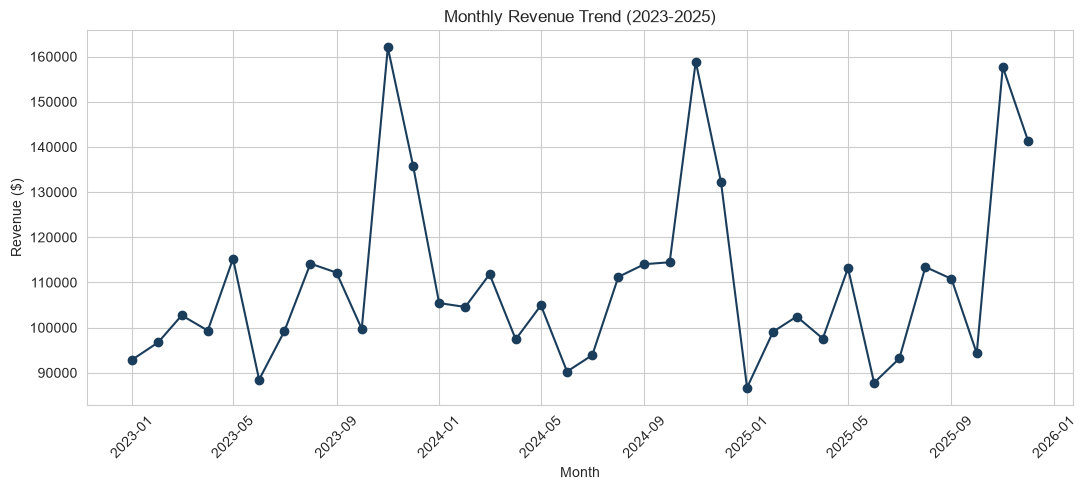

In [2]:
monthly_rev = q('''
    SELECT strftime('%Y-%m', o.order_date) AS year_month,
           SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS revenue
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'Completed'
    GROUP BY year_month ORDER BY year_month
''')
monthly_rev['year_month'] = pd.to_datetime(monthly_rev['year_month'])

fig, ax = plt.subplots()
ax.plot(monthly_rev['year_month'], monthly_rev['revenue'], marker='o', linewidth=1.5, color='#1a3d5c')
ax.set_title('Monthly Revenue Trend (2023-2025)')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Revenue shows a clear, repeating seasonal pattern with a November peak (holiday shopping) each year and a January dip. This is a planning input for inventory and marketing timing, not year-over-year growth in itself — see the yearly total comparison below.

year
2023    1.318513e+06
2024    1.339231e+06
2025    1.297540e+06
Name: revenue, dtype: float64


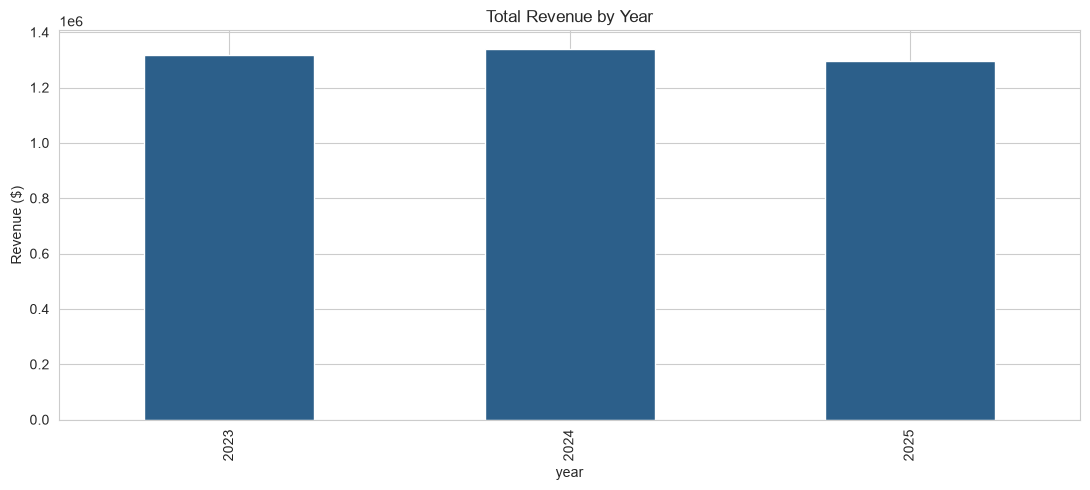

In [3]:
monthly_rev['year'] = monthly_rev['year_month'].dt.year
yearly = monthly_rev.groupby('year')['revenue'].sum()
print(yearly)
yearly.plot(kind='bar', color='#2c5f8a', title='Total Revenue by Year')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()


### Revenue by category and channel

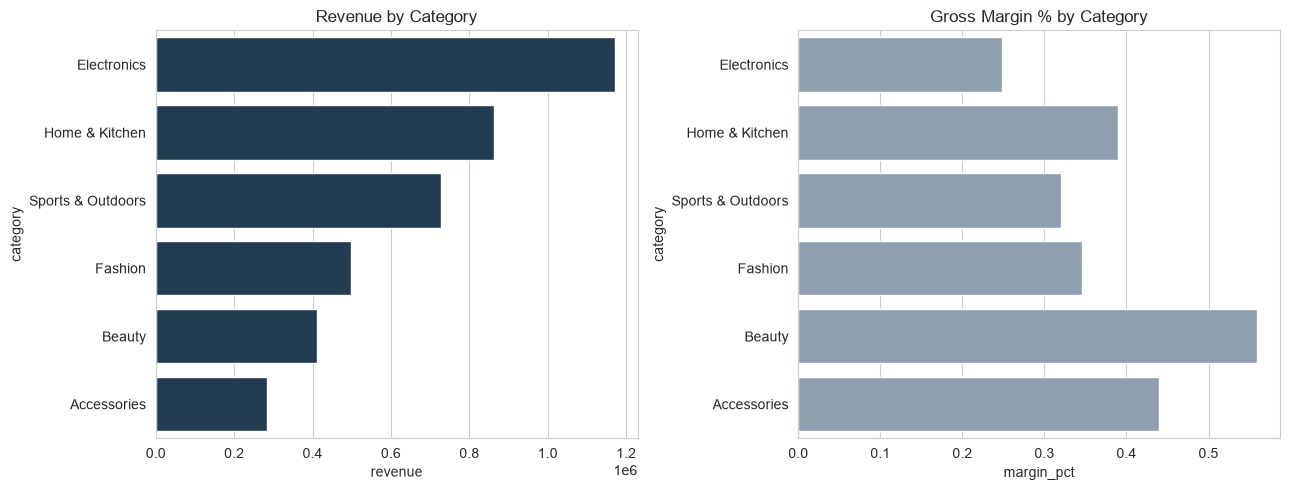

,category,revenue,margin_pct
0,Electronics,1.170546e+06,0.247693
1,Home & Kitchen,8.633870e+05,0.389549
2,Sports & Outdoors,7.268643e+05,0.320583
3,Fashion,4.988084e+05,0.345289
4,Beauty,4.111049e+05,0.559185
5,Accessories,2.845724e+05,0.439968


In [4]:
cat_rev = q('''
    SELECT p.category, SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS revenue,
           (SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) - SUM(oi.quantity * oi.cost))
             / SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS margin_pct
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN products p ON oi.product_id = p.product_id
    WHERE o.order_status = 'Completed'
    GROUP BY p.category ORDER BY revenue DESC
''')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=cat_rev, x='revenue', y='category', ax=axes[0], color='#1a3d5c')
axes[0].set_title('Revenue by Category')
sns.barplot(data=cat_rev, x='margin_pct', y='category', ax=axes[1], color='#8a9fb5')
axes[1].set_title('Gross Margin % by Category')
plt.tight_layout()
plt.show()
cat_rev


**Insight:** Electronics leads revenue but has the weakest margin of the major categories — the classic 'high revenue, low margin' quadrant that needs cost or pricing review rather than a promotion push.

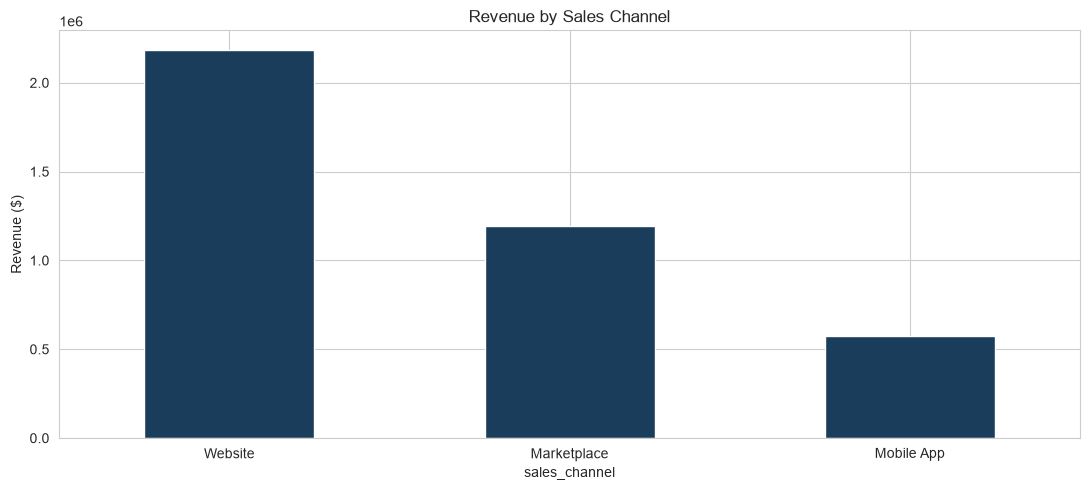

In [5]:
channel_rev = q('''
    SELECT o.sales_channel, COUNT(DISTINCT o.order_id) AS orders,
           SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS revenue
    FROM order_items oi JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'Completed'
    GROUP BY o.sales_channel ORDER BY revenue DESC
''')
channel_rev.plot(kind='bar', x='sales_channel', y='revenue', legend=False, color='#1a3d5c', title='Revenue by Sales Channel')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Order Analysis

**Business question:** What does a typical order look like, and how much does it vary?

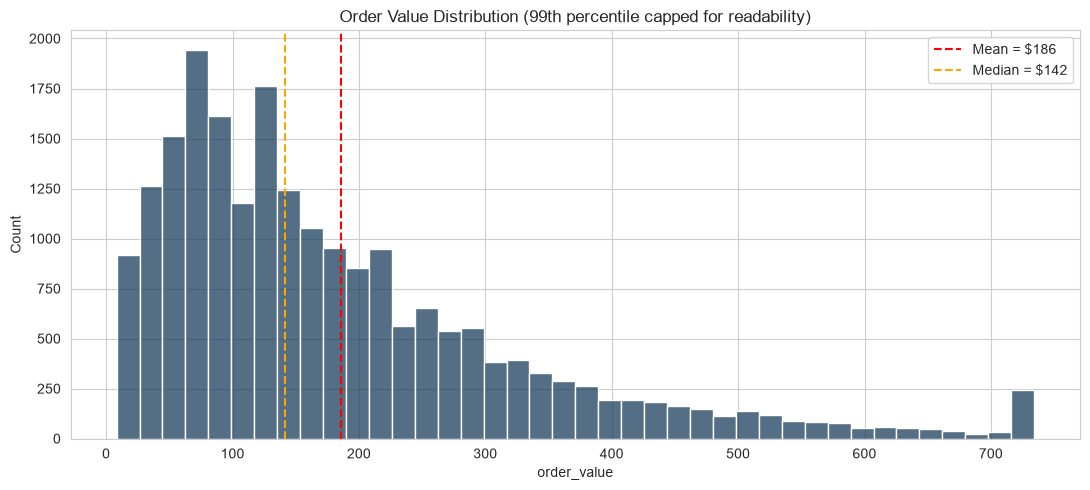

In [6]:
order_val = q('''
    SELECT oi.order_id, SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS order_value
    FROM order_items oi JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'Completed'
    GROUP BY oi.order_id
''')

fig, ax = plt.subplots()
sns.histplot(order_val['order_value'].clip(upper=order_val['order_value'].quantile(0.99)), bins=40, color='#1a3d5c', ax=ax)
ax.axvline(order_val['order_value'].mean(), color='red', linestyle='--', label=f"Mean = ${order_val['order_value'].mean():.0f}")
ax.axvline(order_val['order_value'].median(), color='orange', linestyle='--', label=f"Median = ${order_val['order_value'].median():.0f}")
ax.set_title('Order Value Distribution (99th percentile capped for readability)')
ax.legend()
plt.tight_layout()
plt.show()


**Insight:** Order value is right-skewed (mean > median), typical of retail — a smaller number of larger baskets pull the average up. AOV reporting should favor median or a trimmed mean alongside the headline AOV.

## 3. Customer Analysis

**Business question:** How is revenue distributed across customers, and how loyal is the base?

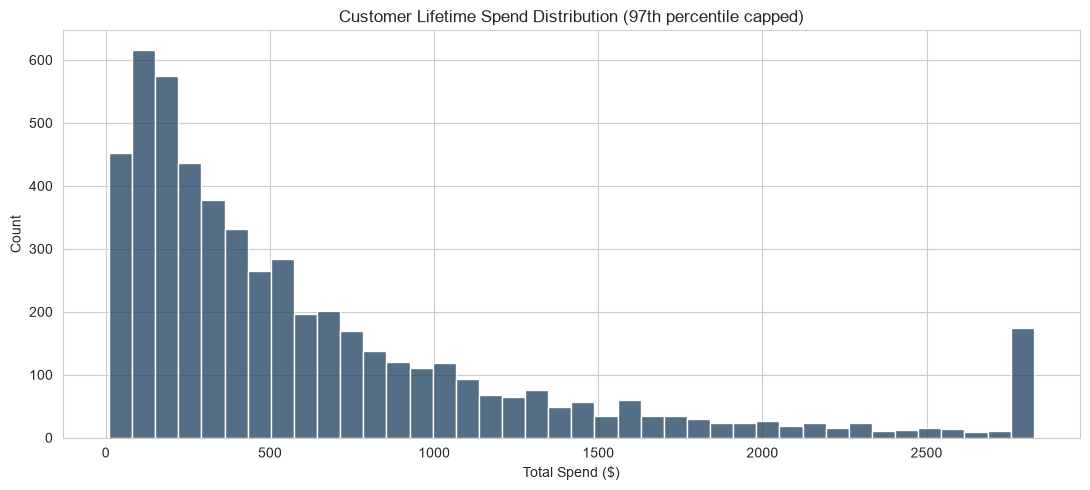

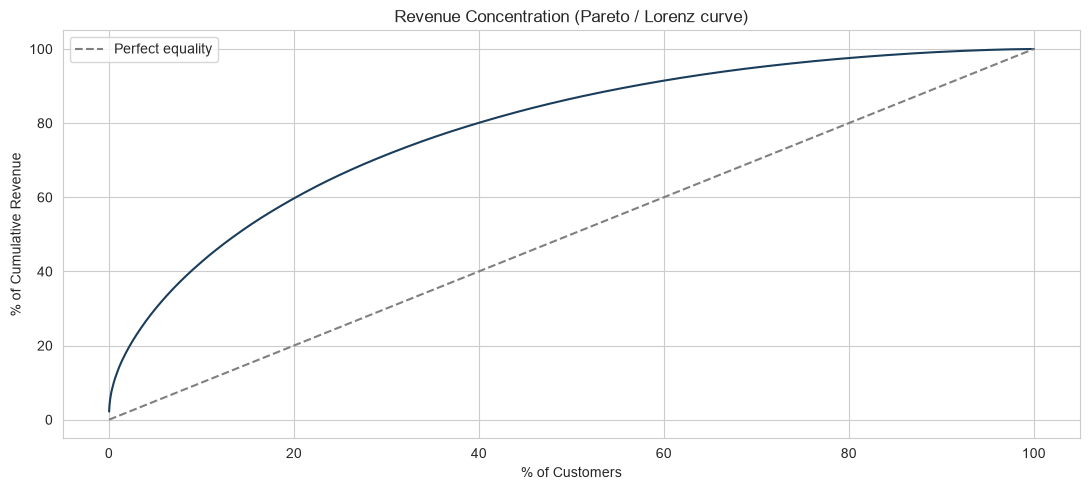

Top 25% of customers generate 66.1% of revenue


In [7]:
cust_rev = q('''
    SELECT o.customer_id, SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS total_spend,
           COUNT(DISTINCT o.order_id) AS n_orders
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id
    WHERE o.order_status = 'Completed'
    GROUP BY o.customer_id
''')

fig, ax = plt.subplots()
sns.histplot(cust_rev['total_spend'].clip(upper=cust_rev['total_spend'].quantile(0.97)), bins=40, color='#1a3d5c')
ax.set_title('Customer Lifetime Spend Distribution (97th percentile capped)')
ax.set_xlabel('Total Spend ($)')
plt.tight_layout()
plt.show()

# Pareto check
cust_rev_sorted = cust_rev.sort_values('total_spend', ascending=False).reset_index(drop=True)
cust_rev_sorted['cum_pct_revenue'] = cust_rev_sorted['total_spend'].cumsum() / cust_rev_sorted['total_spend'].sum()
cust_rev_sorted['cum_pct_customers'] = (cust_rev_sorted.index + 1) / len(cust_rev_sorted)

fig, ax = plt.subplots()
ax.plot(cust_rev_sorted['cum_pct_customers']*100, cust_rev_sorted['cum_pct_revenue']*100, color='#1a3d5c')
ax.plot([0,100],[0,100], linestyle='--', color='gray', label='Perfect equality')
ax.set_xlabel('% of Customers')
ax.set_ylabel('% of Cumulative Revenue')
ax.set_title('Revenue Concentration (Pareto / Lorenz curve)')
ax.legend()
plt.tight_layout()
plt.show()

top25_share = cust_rev_sorted.loc[cust_rev_sorted['cum_pct_customers'] <= 0.25, 'total_spend'].sum() / cust_rev_sorted['total_spend'].sum()
print(f"Top 25% of customers generate {top25_share:.1%} of revenue")


**Insight:** Revenue is heavily concentrated in a small share of customers — confirms the RFM/quartile findings in the business report and justifies a dedicated retention strategy for top-value customers rather than uniform treatment.

### Repeat purchase behavior

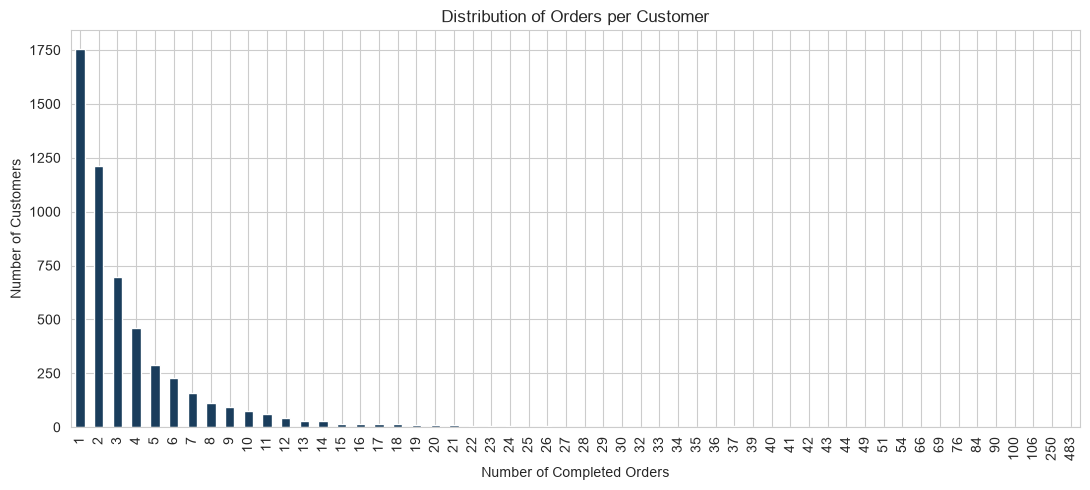

Repeat purchase rate: 67.5%


In [8]:
order_counts = cust_rev['n_orders'].value_counts().sort_index()
order_counts.plot(kind='bar', color='#1a3d5c', title='Distribution of Orders per Customer')
plt.xlabel('Number of Completed Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

repeat_rate = (cust_rev['n_orders'] >= 2).mean()
print(f"Repeat purchase rate: {repeat_rate:.1%}")


## 4. Product Analysis

**Business question:** Which products/categories perform best, and where are return problems concentrated?

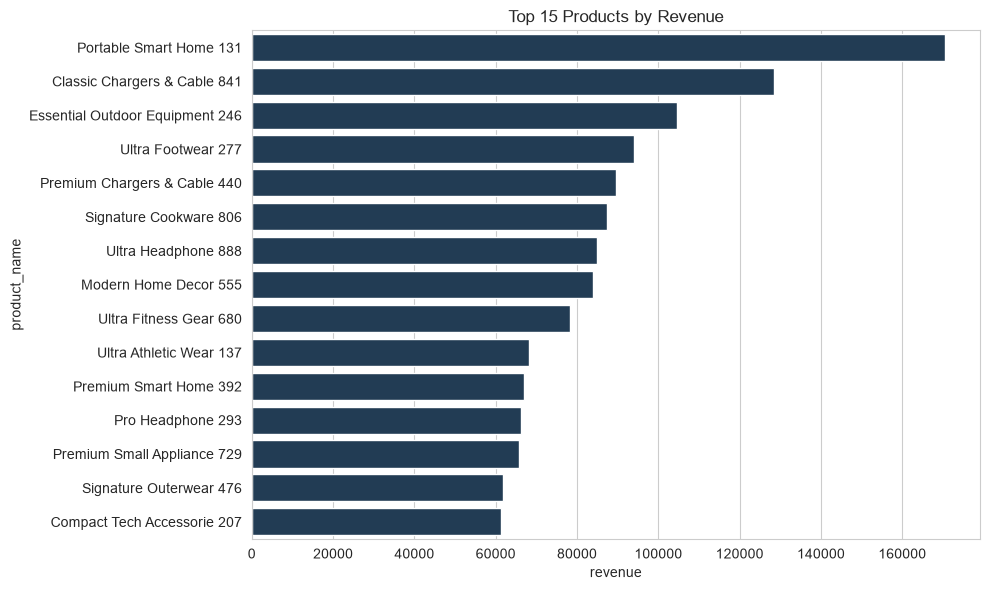

In [9]:
prod_perf = q('''
    SELECT p.product_id, p.product_name, p.category,
           SUM(oi.quantity) AS units_sold,
           SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) AS revenue,
           SUM(oi.quantity * oi.unit_price * (1 - oi.discount)) - SUM(oi.quantity * oi.cost) AS profit
    FROM order_items oi JOIN orders o ON oi.order_id = o.order_id JOIN products p ON oi.product_id = p.product_id
    WHERE o.order_status = 'Completed'
    GROUP BY p.product_id ORDER BY revenue DESC
''')

top15 = prod_perf.head(15)
plt.figure(figsize=(10,6))
sns.barplot(data=top15, x='revenue', y='product_name', color='#1a3d5c')
plt.title('Top 15 Products by Revenue')
plt.tight_layout()
plt.show()


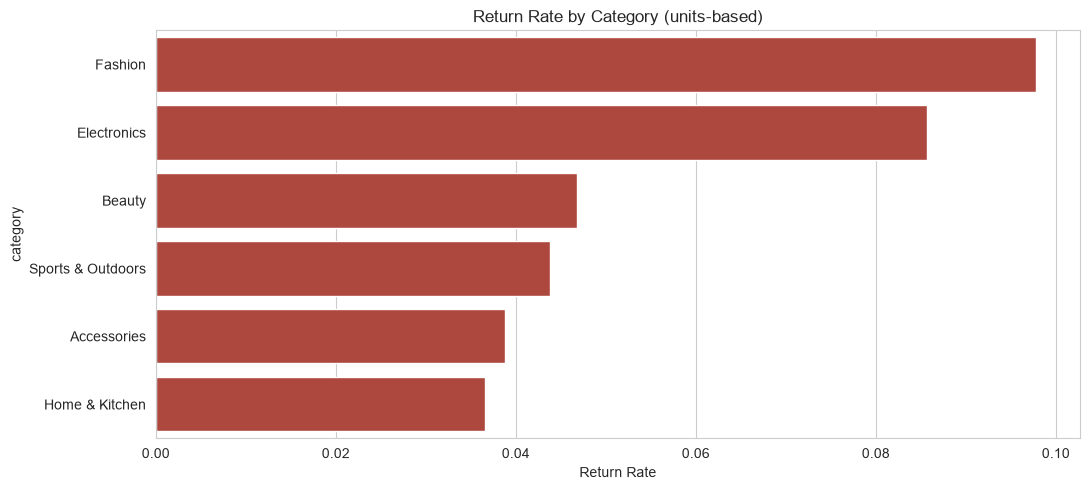

,category,units_sold,units_returned,return_rate
0,Fashion,6698,655,0.097790
1,Electronics,7967,683,0.085729
2,Beauty,7654,358,0.046773
3,Sports & Outdoors,5003,219,0.043774
4,Accessories,4663,181,0.038816
5,Home & Kitchen,7089,259,0.036535


In [10]:
return_rate = q('''
    WITH sold AS (
        SELECT p.category, oi.product_id, SUM(oi.quantity) units_sold
        FROM order_items oi JOIN orders o ON oi.order_id = o.order_id JOIN products p ON oi.product_id = p.product_id
        WHERE o.order_status = 'Completed' GROUP BY p.category, oi.product_id
    ),
    ret AS (SELECT product_id, SUM(returned_quantity) units_returned FROM returns GROUP BY product_id)
    SELECT s.category, SUM(s.units_sold) units_sold, SUM(COALESCE(r.units_returned,0)) units_returned,
           1.0*SUM(COALESCE(r.units_returned,0))/SUM(s.units_sold) AS return_rate
    FROM sold s LEFT JOIN ret r ON r.product_id = s.product_id
    GROUP BY s.category ORDER BY return_rate DESC
''')

sns.barplot(data=return_rate, x='return_rate', y='category', color='#c0392b')
plt.title('Return Rate by Category (units-based)')
plt.xlabel('Return Rate')
plt.tight_layout()
plt.show()
return_rate


**Insight:** Fashion and Electronics have the highest return rates. Fashion returns are typically fit-related (actionable via better sizing guides); Electronics returns are more often defect-related and worth a supplier quality conversation.

## 5. Marketing Analysis

**Business question:** Which channels are actually worth the spend?

C:\Users\tanic\AppData\Local\Temp\ipykernel_19080\3349665267.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mkt, x='roas', y='channel', palette=colors, ax=ax)


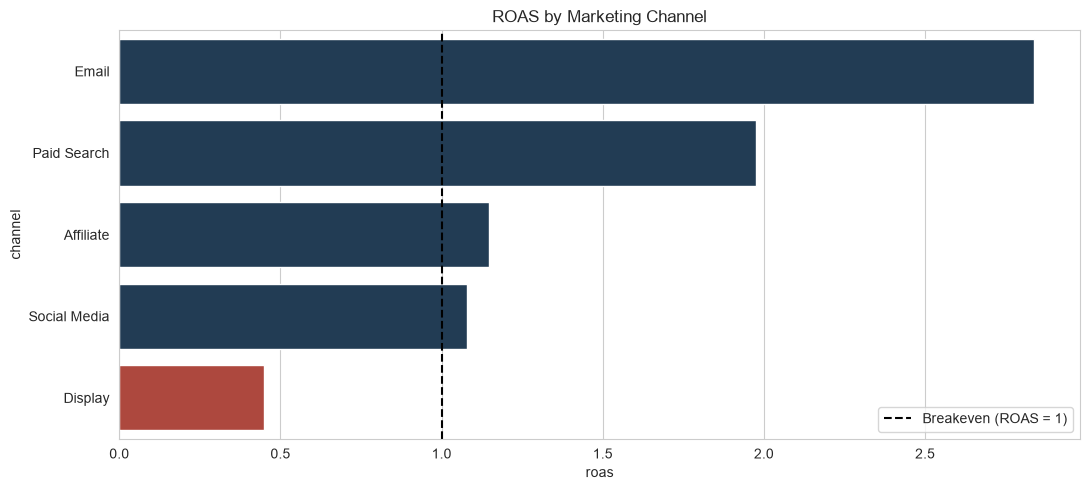

,channel,spend,clicks,conversions,attributed_revenue,roas
0,Email,378319.79,198838,14091,1073957.94,2.838757
1,Paid Search,245406.23,143769,6469,484413.61,1.973925
2,Affiliate,407246.77,183247,5623,466886.46,1.146446
3,Social Media,344072.07,179345,4597,371453.19,1.079580
4,Display,291396.39,146452,1749,131080.57,0.449836


In [11]:
mkt = q('''
    SELECT channel, SUM(spend) AS spend, SUM(clicks) AS clicks, SUM(conversions) AS conversions,
           SUM(attributed_revenue) AS attributed_revenue,
           SUM(attributed_revenue) / SUM(spend) AS roas
    FROM marketing GROUP BY channel ORDER BY roas DESC
''')

fig, ax = plt.subplots()
colors = ['#1a3d5c' if r >= 1 else '#c0392b' for r in mkt['roas']]
sns.barplot(data=mkt, x='roas', y='channel', palette=colors, ax=ax)
ax.axvline(1.0, color='black', linestyle='--', label='Breakeven (ROAS = 1)')
ax.set_title('ROAS by Marketing Channel')
ax.legend()
plt.tight_layout()
plt.show()
mkt


**Insight:** Email delivers by far the best ROAS despite modest spend; Display is below breakeven. This directly supports the budget-reallocation recommendation in the business report.

## Summary

This EDA confirms and quantifies the findings written up in `reports/business_insights.md`:
- Flat but seasonal revenue
- Heavy revenue concentration in top customers (Pareto pattern)
- Electronics: high revenue, comparatively low margin
- Fashion/Electronics: highest return rates
- Email: best marketing ROI; Display: underperforming

Next: `03_customer_analysis.ipynb` (or `src/feature_engineering.py` output) goes deeper into RFM segmentation and cohort retention.
